In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#importing the dataset
df=pd.read_csv("/content/Crop_recommendation.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [10]:
df.tail()#reviewing the last five rows

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [11]:
df.shape

(2200, 8)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [13]:
df.describe() #statistical information

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [14]:
df.dtypes

,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [15]:
df.isnull().sum() #checking null values

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


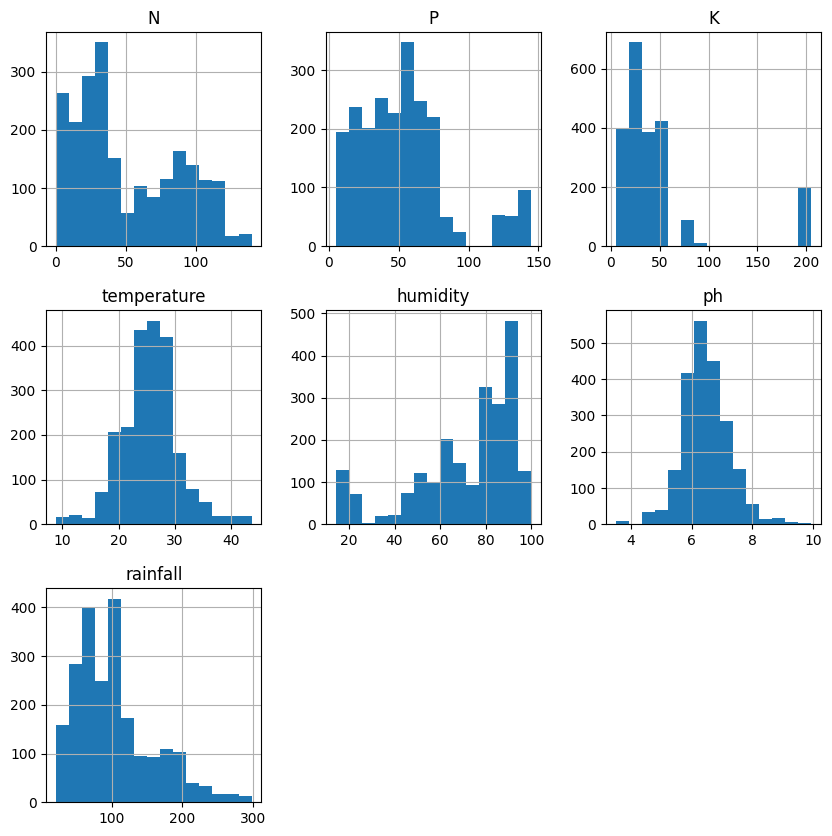

In [16]:
df.hist(bins=15,figsize=(10,10))
plt.show()

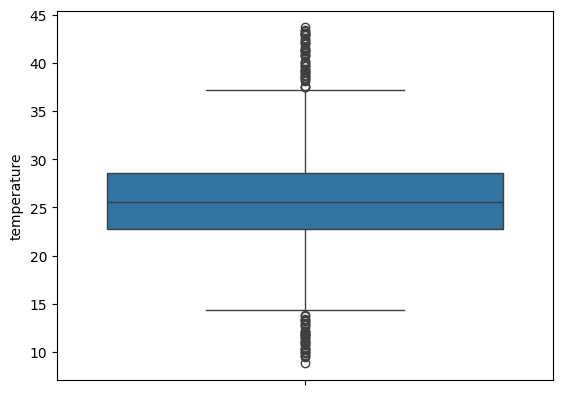

In [17]:
sns.boxplot(y='temperature',data=df)
plt.show()

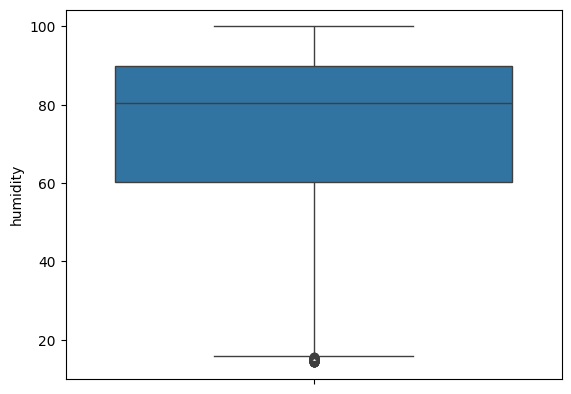

In [18]:
sns.boxplot(y='humidity',data=df)
plt.show()

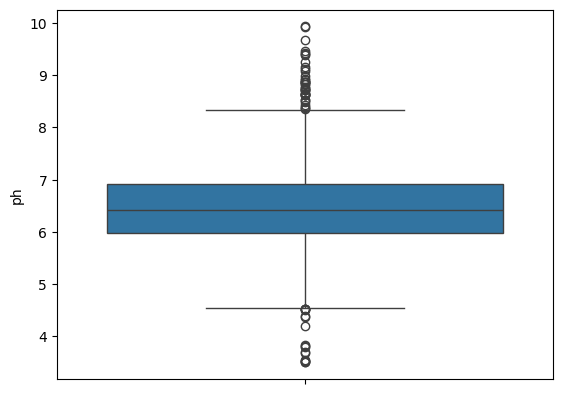

In [19]:
sns.boxplot(y='ph',data=df)
plt.show()

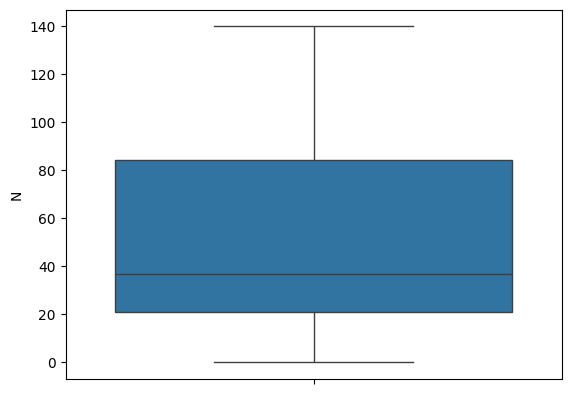

In [20]:
sns.boxplot(y='N',data=df)
plt.show()

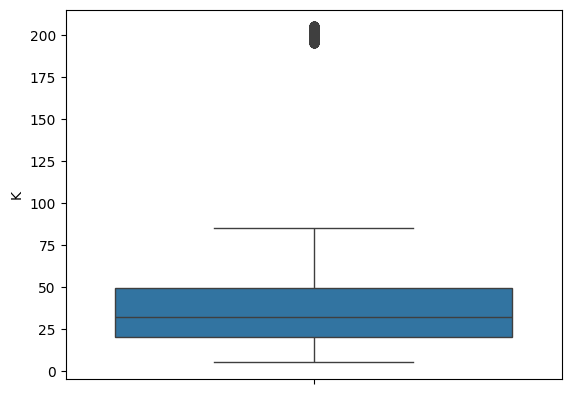

In [21]:
sns.boxplot(y='K',data=df)
plt.show()

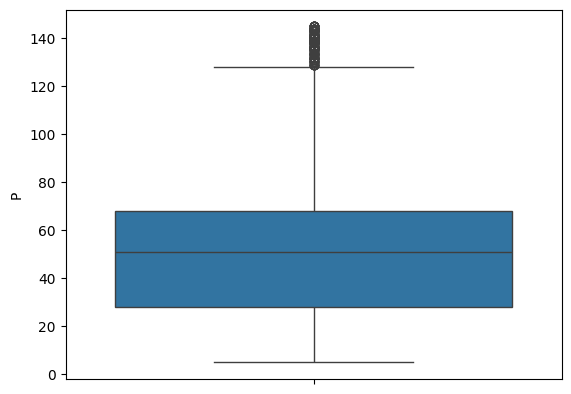

In [22]:
sns.boxplot(y='P',data=df)
plt.show()

In [23]:
def remove_outliers(col_name):
  sorted(col_name)
  Q1,Q3=col_name.quantile([0.25,0.75])
  IQR=Q3-Q1
  lower_range=Q1-(1.5*IQR)
  upper_range=Q3+(1.5*IQR)
  return lower_range,upper_range

In [24]:
low,high=remove_outliers(df['P'])


In [25]:
df['P']=np.where(df['P']>high,high,np.where(df['P']<low,low,df['P']))

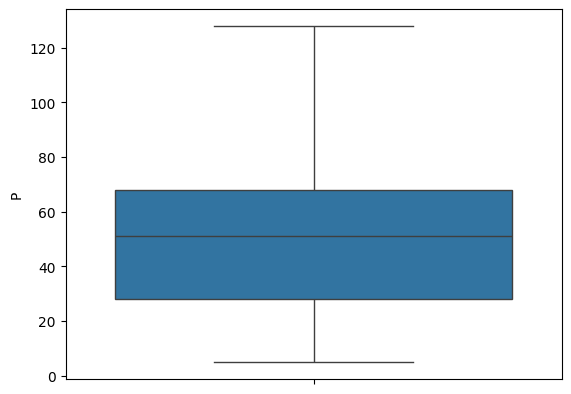

In [26]:
sns.boxplot(y='P',data=df)
plt.show()

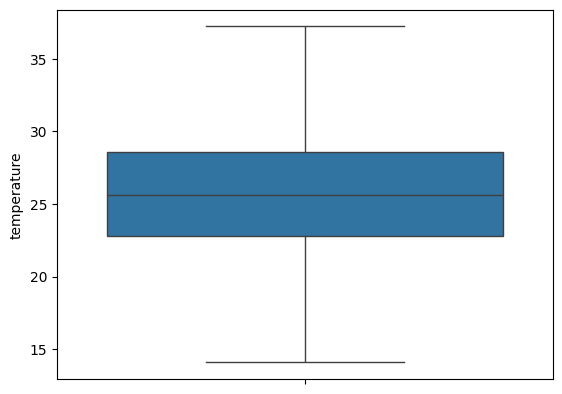

In [27]:
low,high=remove_outliers(df['temperature'])
df['temperature']=np.where(df['temperature']>high,high,np.where(df['temperature']<low,low,df['temperature']))
sns.boxplot(y='temperature',data=df)
plt.show()

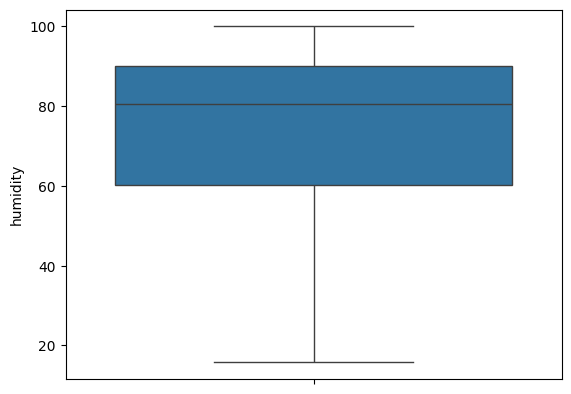

In [28]:
low,high=remove_outliers(df['humidity'])
df['humidity']=np.where(df['humidity']>high,high,np.where(df['humidity']<low,low,df['humidity']))
sns.boxplot(y='humidity',data=df)
plt.show()

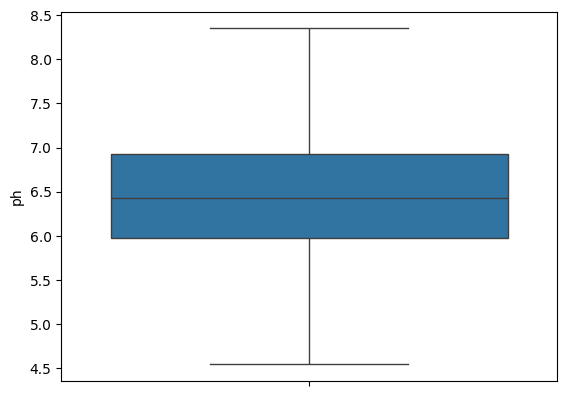

In [29]:
low,high=remove_outliers(df['ph'])
df['ph']=np.where(df['ph']>high,high,np.where(df['ph']<low,low,df['ph']))
sns.boxplot(y='ph',data=df)
plt.show()

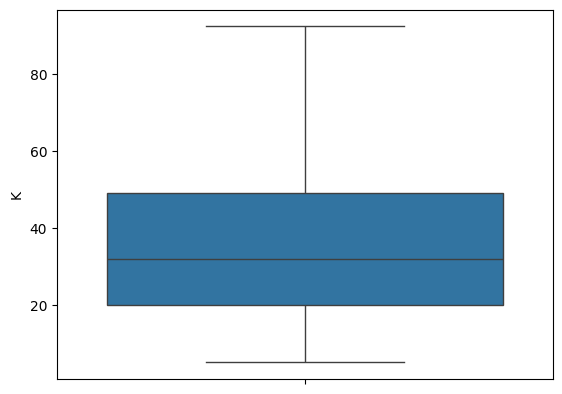

In [30]:
low,high=remove_outliers(df['K'])
df['K']=np.where(df['K']>high,high,np.where(df['K']<low,low,df['K']))
sns.boxplot(y='K',data=df)
plt.show()

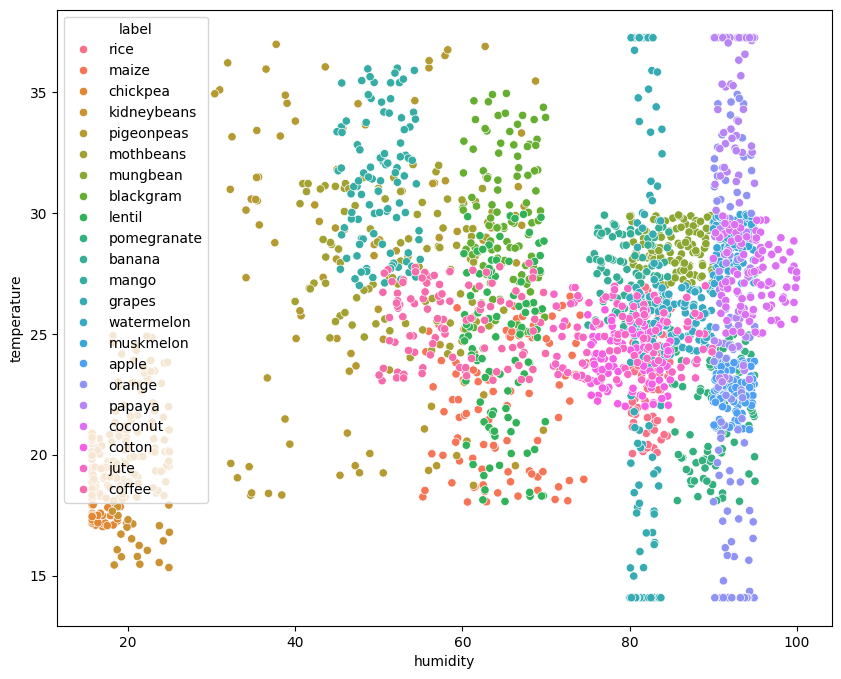

In [31]:
#Humidity v/s Temperature
plt.figure(figsize=(10,8))
sns.scatterplot(x='humidity',y='temperature',data=df,hue='label')
plt.show()

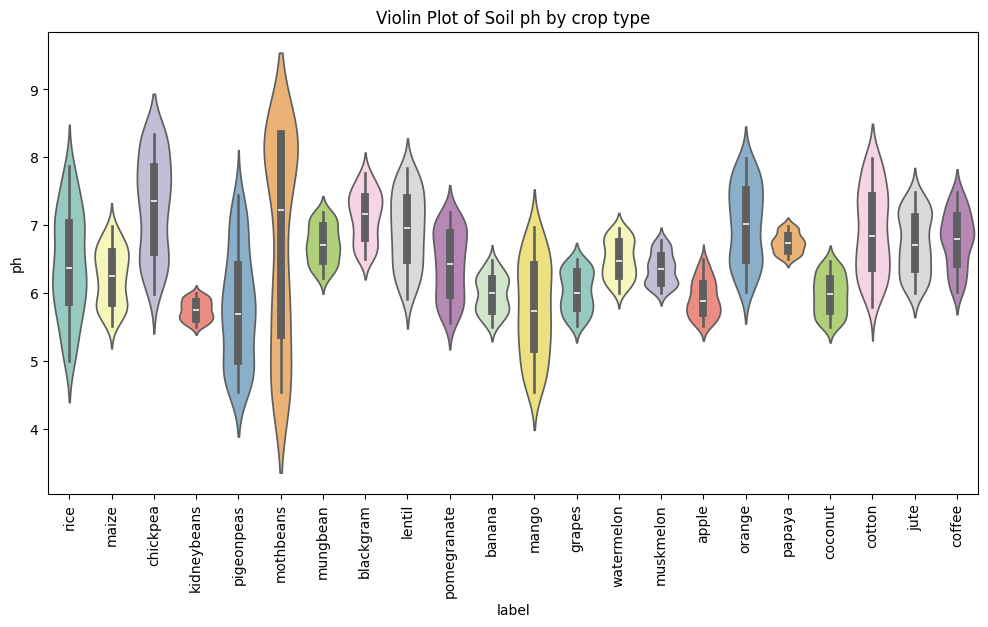

In [32]:
plt.figure(figsize=(12,6))
sns.violinplot(x='label',y='ph',data=df,hue='label',palette='Set3')
plt.title("Violin Plot of Soil ph by crop type")
plt.xticks(rotation=90)
plt.show()

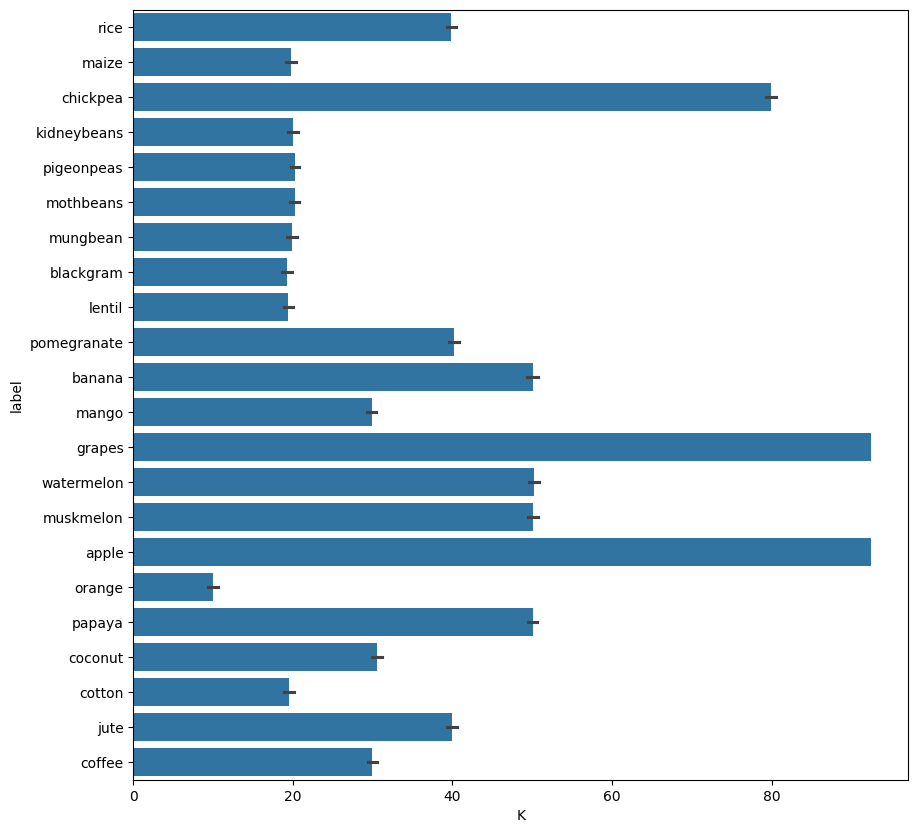

In [33]:
plt.figure(figsize=(10,10))
sns.barplot(y='label',x='K',data=df)
plt.show()

In [34]:
df.groupby(['label'])['P'].mean().sort_values(ascending=False)

,P
label,
apple,126.66
grapes,126.46
banana,82.01
lentil,68.36
chickpea,67.79
pigeonpeas,67.73
kidneybeans,67.54
blackgram,67.47
papaya,59.05
